In [1]:
import torch
from torch import nn
from torch.nn import functional as F

import matplotlib.pyplot as plt
import numpy as np

In [54]:
x = torch.randn(2, 5)
cov = x[..., None] @ x[..., None].transpose(-1, -2)

u, s, v = torch.svd(cov)

u.shape, s.shape, v.shape

(torch.Size([2, 5, 5]), torch.Size([2, 5]), torch.Size([2, 5, 5]))

In [58]:
x = torch.randn(2, 5, 1)

u, s, v = torch.svd(x)

u.shape, s.shape, v.shape

(torch.Size([2, 5, 1]), torch.Size([2, 1]), torch.Size([2, 1, 1]))

In [64]:


u * s[..., None] * v, x

(tensor([[[ 0.1532],
          [ 1.4848],
          [-0.5530],
          [ 1.1397],
          [-1.2455]],
 
         [[ 0.1778],
          [-1.1385],
          [ 0.8455],
          [-1.8547],
          [-0.2791]]]),
 tensor([[[ 0.1532],
          [ 1.4848],
          [-0.5530],
          [ 1.1397],
          [-1.2455]],
 
         [[ 0.1778],
          [-1.1385],
          [ 0.8455],
          [-1.8547],
          [-0.2791]]]))

In [176]:
class EigenMLP(nn.Module):
    
    def __init__(self, d, out_dim):
        super().__init__()
        self.emb = nn.LazyLinear(d)
        self.unemb = nn.LazyLinear(out_dim)
        self.theta = nn.Parameter(torch.randn(1))
        self.norm = nn.LayerNorm(normalized_shape=(d, 1))
        
    def forward(self, x):
        # input x must have shape: (batch_size, n)

        x = self.emb(x)[..., None]
        u, s, v = torch.svd(x)
        x_tilde = u * torch.exp(self.theta * s[..., None]) * v
        x = x + self.norm(x_tilde)
        x = torch.relu(x.squeeze())
        y = self.unemb(x)

        return y
    
x = torch.randn(64, 28*28)
mlp = EigenMLP(d=24, out_dim=10)
mlp(x).shape

torch.Size([64, 10])

In [177]:
import torchvision
import torchvision.transforms as transforms

DOWNLOAD_PATH = '../datasets'

# normalize so that the mean of the data is zero and the variance is one
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])

train_val = torchvision.datasets.MNIST(root=DOWNLOAD_PATH, train=True, download=True, transform=transform)
test = torchvision.datasets.MNIST(root=DOWNLOAD_PATH, train=False, download=True, transform=transform)
train, val = torch.utils.data.random_split(train_val, [55000, 5000])

len(train), len(val), len(test)

(55000, 5000, 10000)

In [178]:
from torch.utils.data import DataLoader

batch_size = 64
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test, batch_size=len(test), shuffle=True, drop_last=True)
val_loader = DataLoader(val, batch_size=len(val), shuffle=True, drop_last=True)

In [179]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [206]:
def train_MNIST(model, lr, epochs, verbose=False):
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    train_history = []
    val_history = []

    for e in range(epochs):
        batch_history = []
        # TRAIN STEP
        for images, labels in train_loader:
            # convert images to the correct device (GPU or CPU)
            images, labels = images.flatten(start_dim=1).to(device), labels.to(device)
            # predict and compute loss
            preds = model(images)
            loss = F.cross_entropy(preds, labels)
            batch_history.append(loss.item())
            # optimization step
            optimizer.zero_grad()
            loss.backward()
            # torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()

        train_history.append(np.mean(batch_history))

        batch_history = []
        # VALIDATION STEP
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.flatten(start_dim=1).to(device), labels.to(device)
                preds = model(images)
                loss = F.cross_entropy(preds, labels)
                batch_history.append(loss.item())
            val_history.append(np.mean(batch_history))
        
        if verbose: print(f"epoch: {e}\ttrain loss: {train_history[-1]:.4f}\tval loss: {val_history[-1]:.4f}")
    
    return train_history, val_history

In [207]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 10
learning_rate = 1e-4

model = EigenMLP(d=24, out_dim=10).to(device)

In [208]:
train_histories, val_histories = [], []

train_history, val_history = train_MNIST(model, learning_rate, EPOCHS, verbose=True)

train_histories.append(train_history)
val_histories.append(val_history)

epoch: 0	train loss: 1.1216	val loss: 0.7049
epoch: 1	train loss: 0.5758	val loss: 0.4665
epoch: 2	train loss: 0.4137	val loss: 0.3640
epoch: 3	train loss: 0.3393	val loss: 0.3093
epoch: 4	train loss: 0.2959	val loss: 0.2797
epoch: 5	train loss: 0.2669	val loss: 0.2676
epoch: 6	train loss: 0.2444	val loss: 0.2400
epoch: 7	train loss: 0.2280	val loss: 0.2313
epoch: 8	train loss: 0.2140	val loss: 0.2138
epoch: 9	train loss: 0.2023	val loss: 0.2137


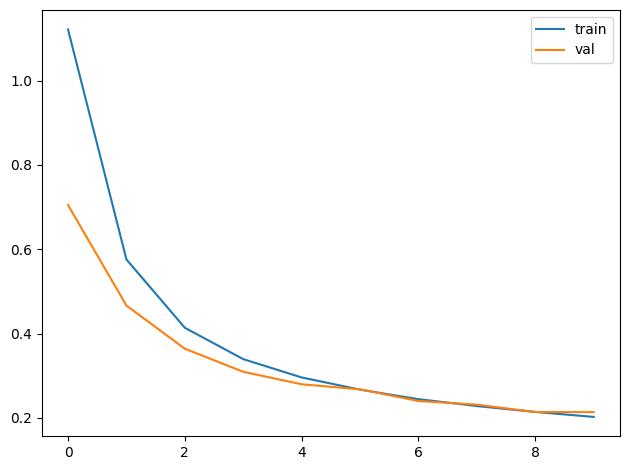

In [209]:
plt.plot(train_histories[0], label='train')
plt.plot(val_histories[0], label='val')
plt.legend()

plt.tight_layout()

In [210]:
test_acc, test_loss = 0, 0
# VALIDATION STEP
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.flatten(start_dim=1).to(device), labels.to(device)
        preds = model(images)
        loss = F.cross_entropy(preds, labels)
        test_loss += loss.item()
        test_acc += sum(preds.argmax(dim=-1) == labels).item()

test_loss, test_acc / len(test)

(0.20365267992019653, 0.94)

In [214]:
theta = model.theta.detach().cpu().numpy()

theta

array([-0.7491657], dtype=float32)